In [1]:
import scanpy as sc

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')

In [2]:
adata = sc.datasets.pbmc3k()

In [3]:
adata.var_names_make_unique()
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['mt'].sum()

np.int64(13)

In [4]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


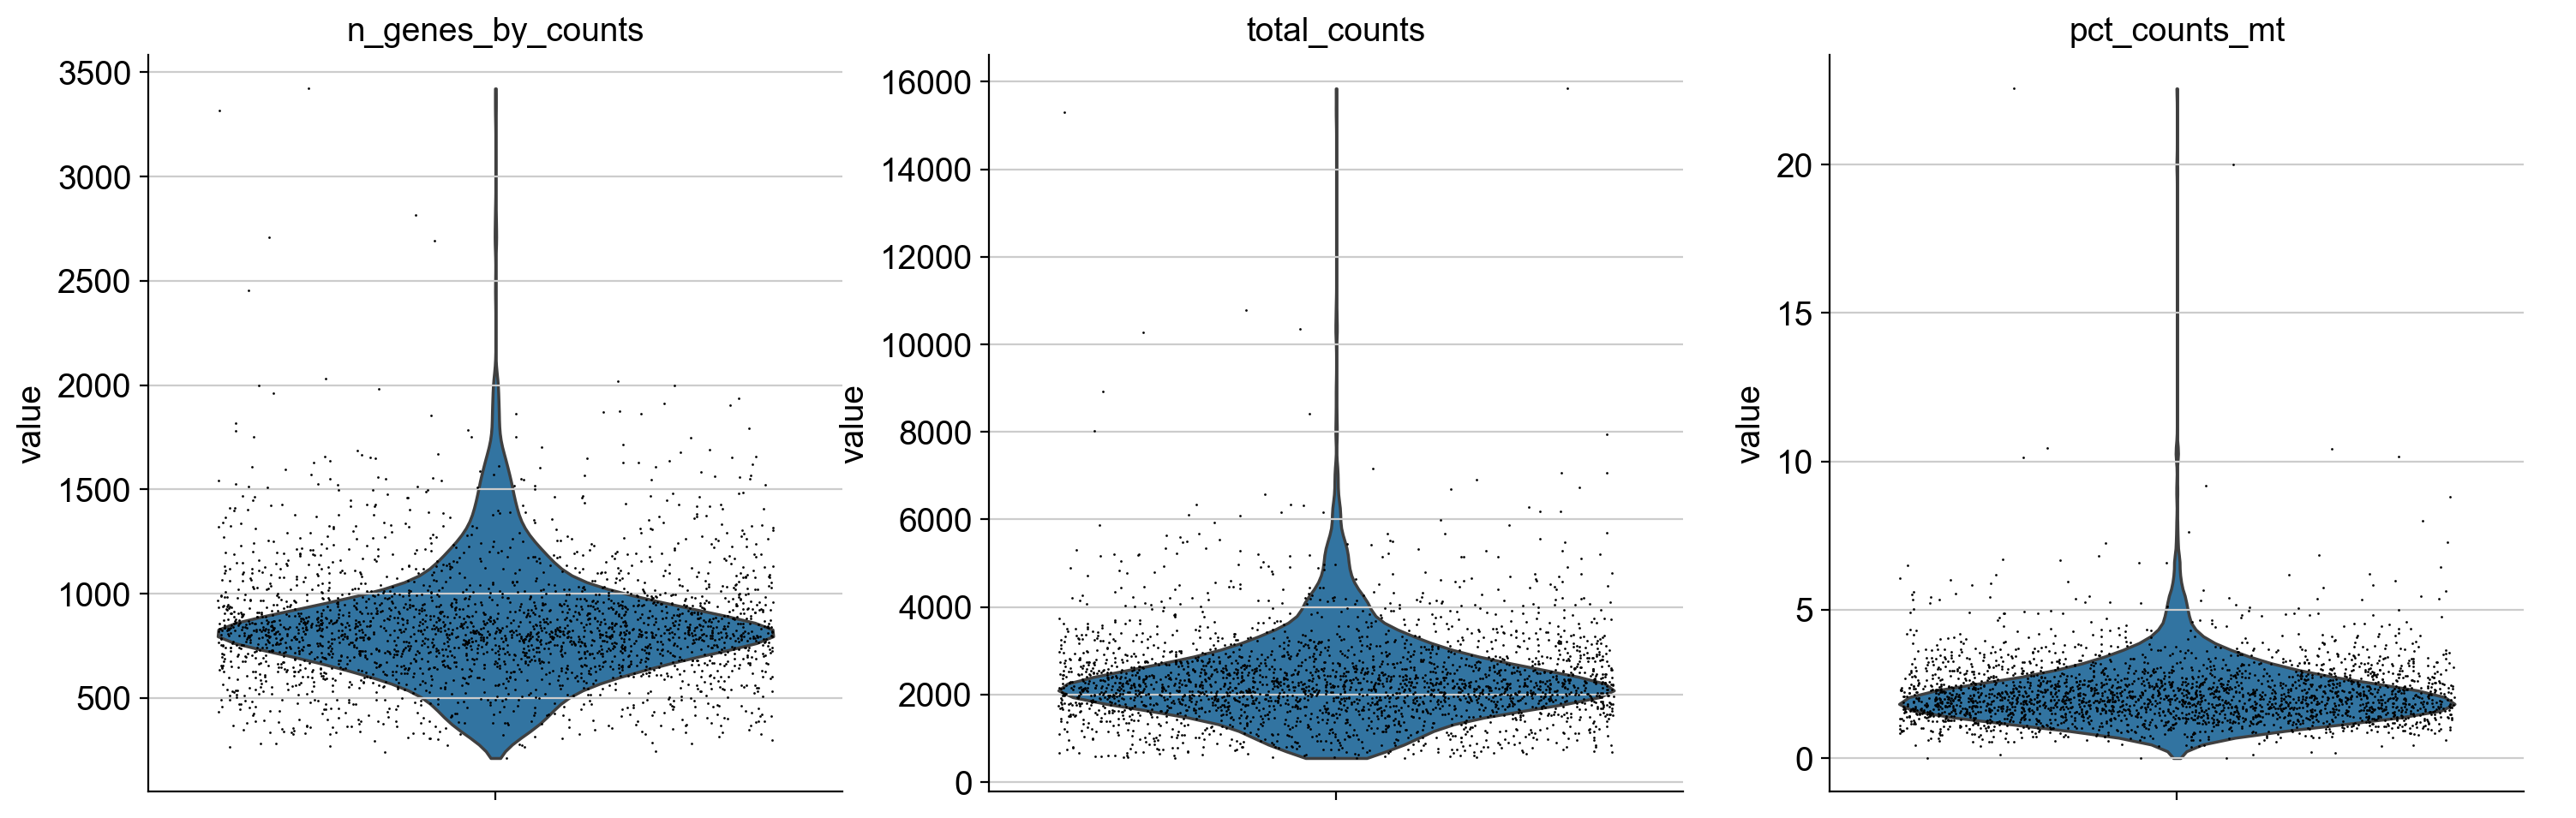

In [7]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

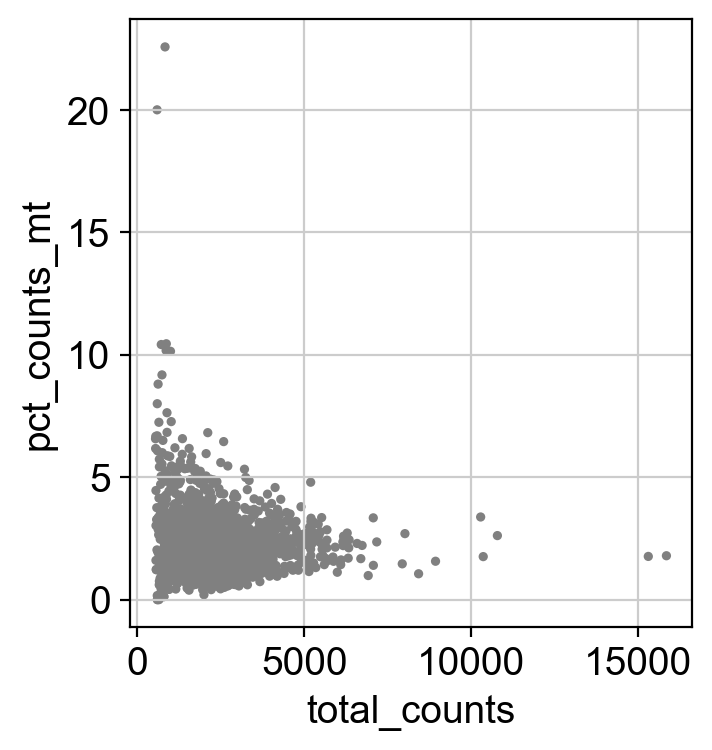

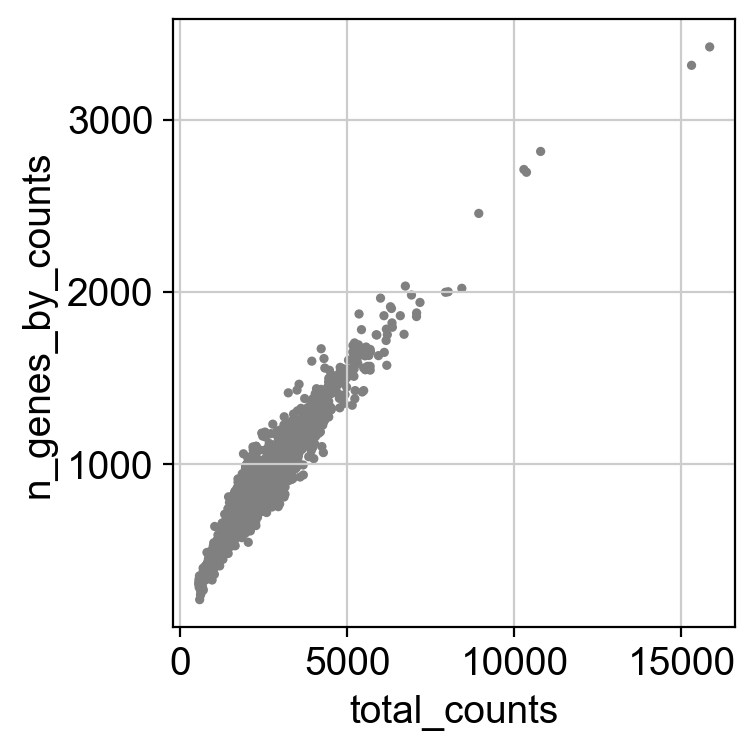

In [8]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [9]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 6, :].copy()
adata

AnnData object with n_obs × n_vars = 2670 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [10]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

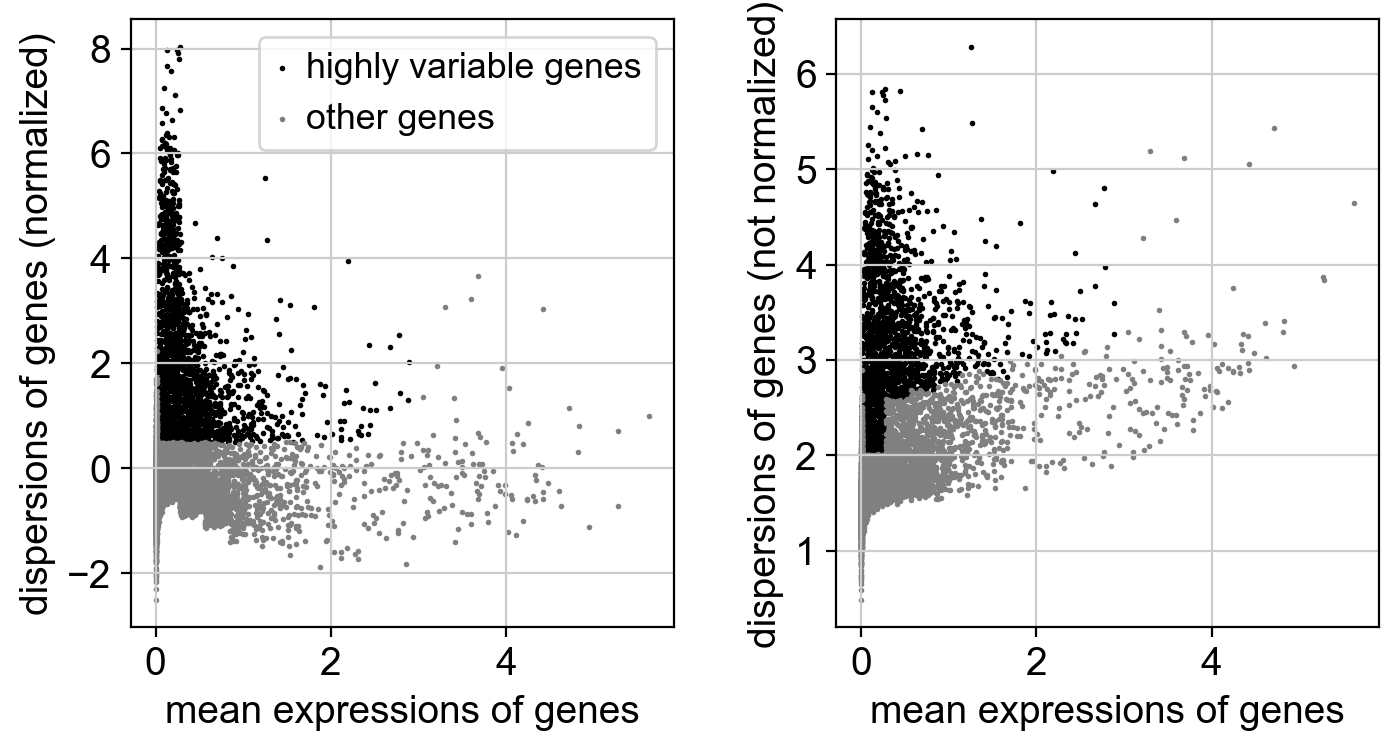

In [11]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

In [16]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

In [15]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata)

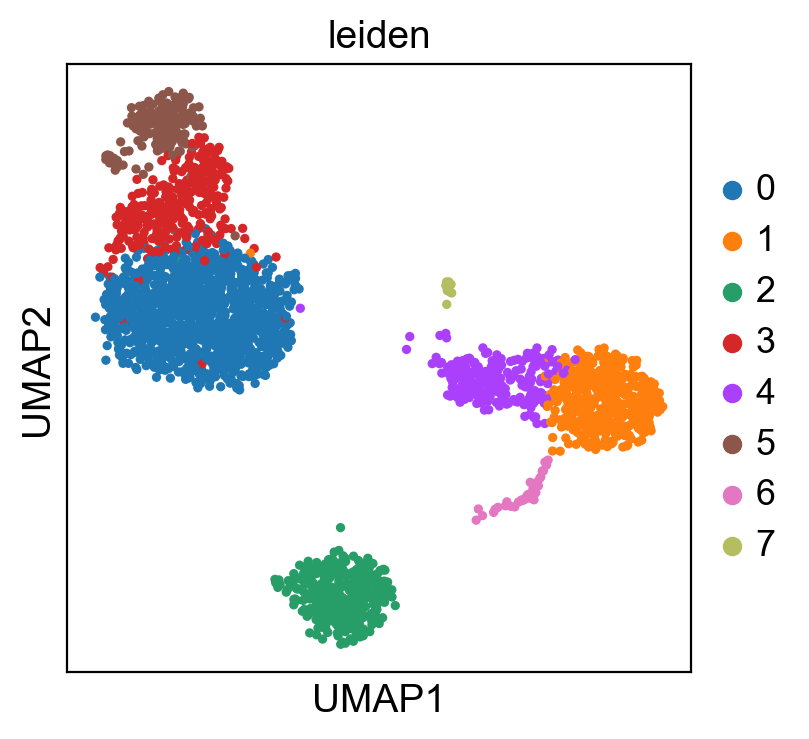

In [17]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden'])

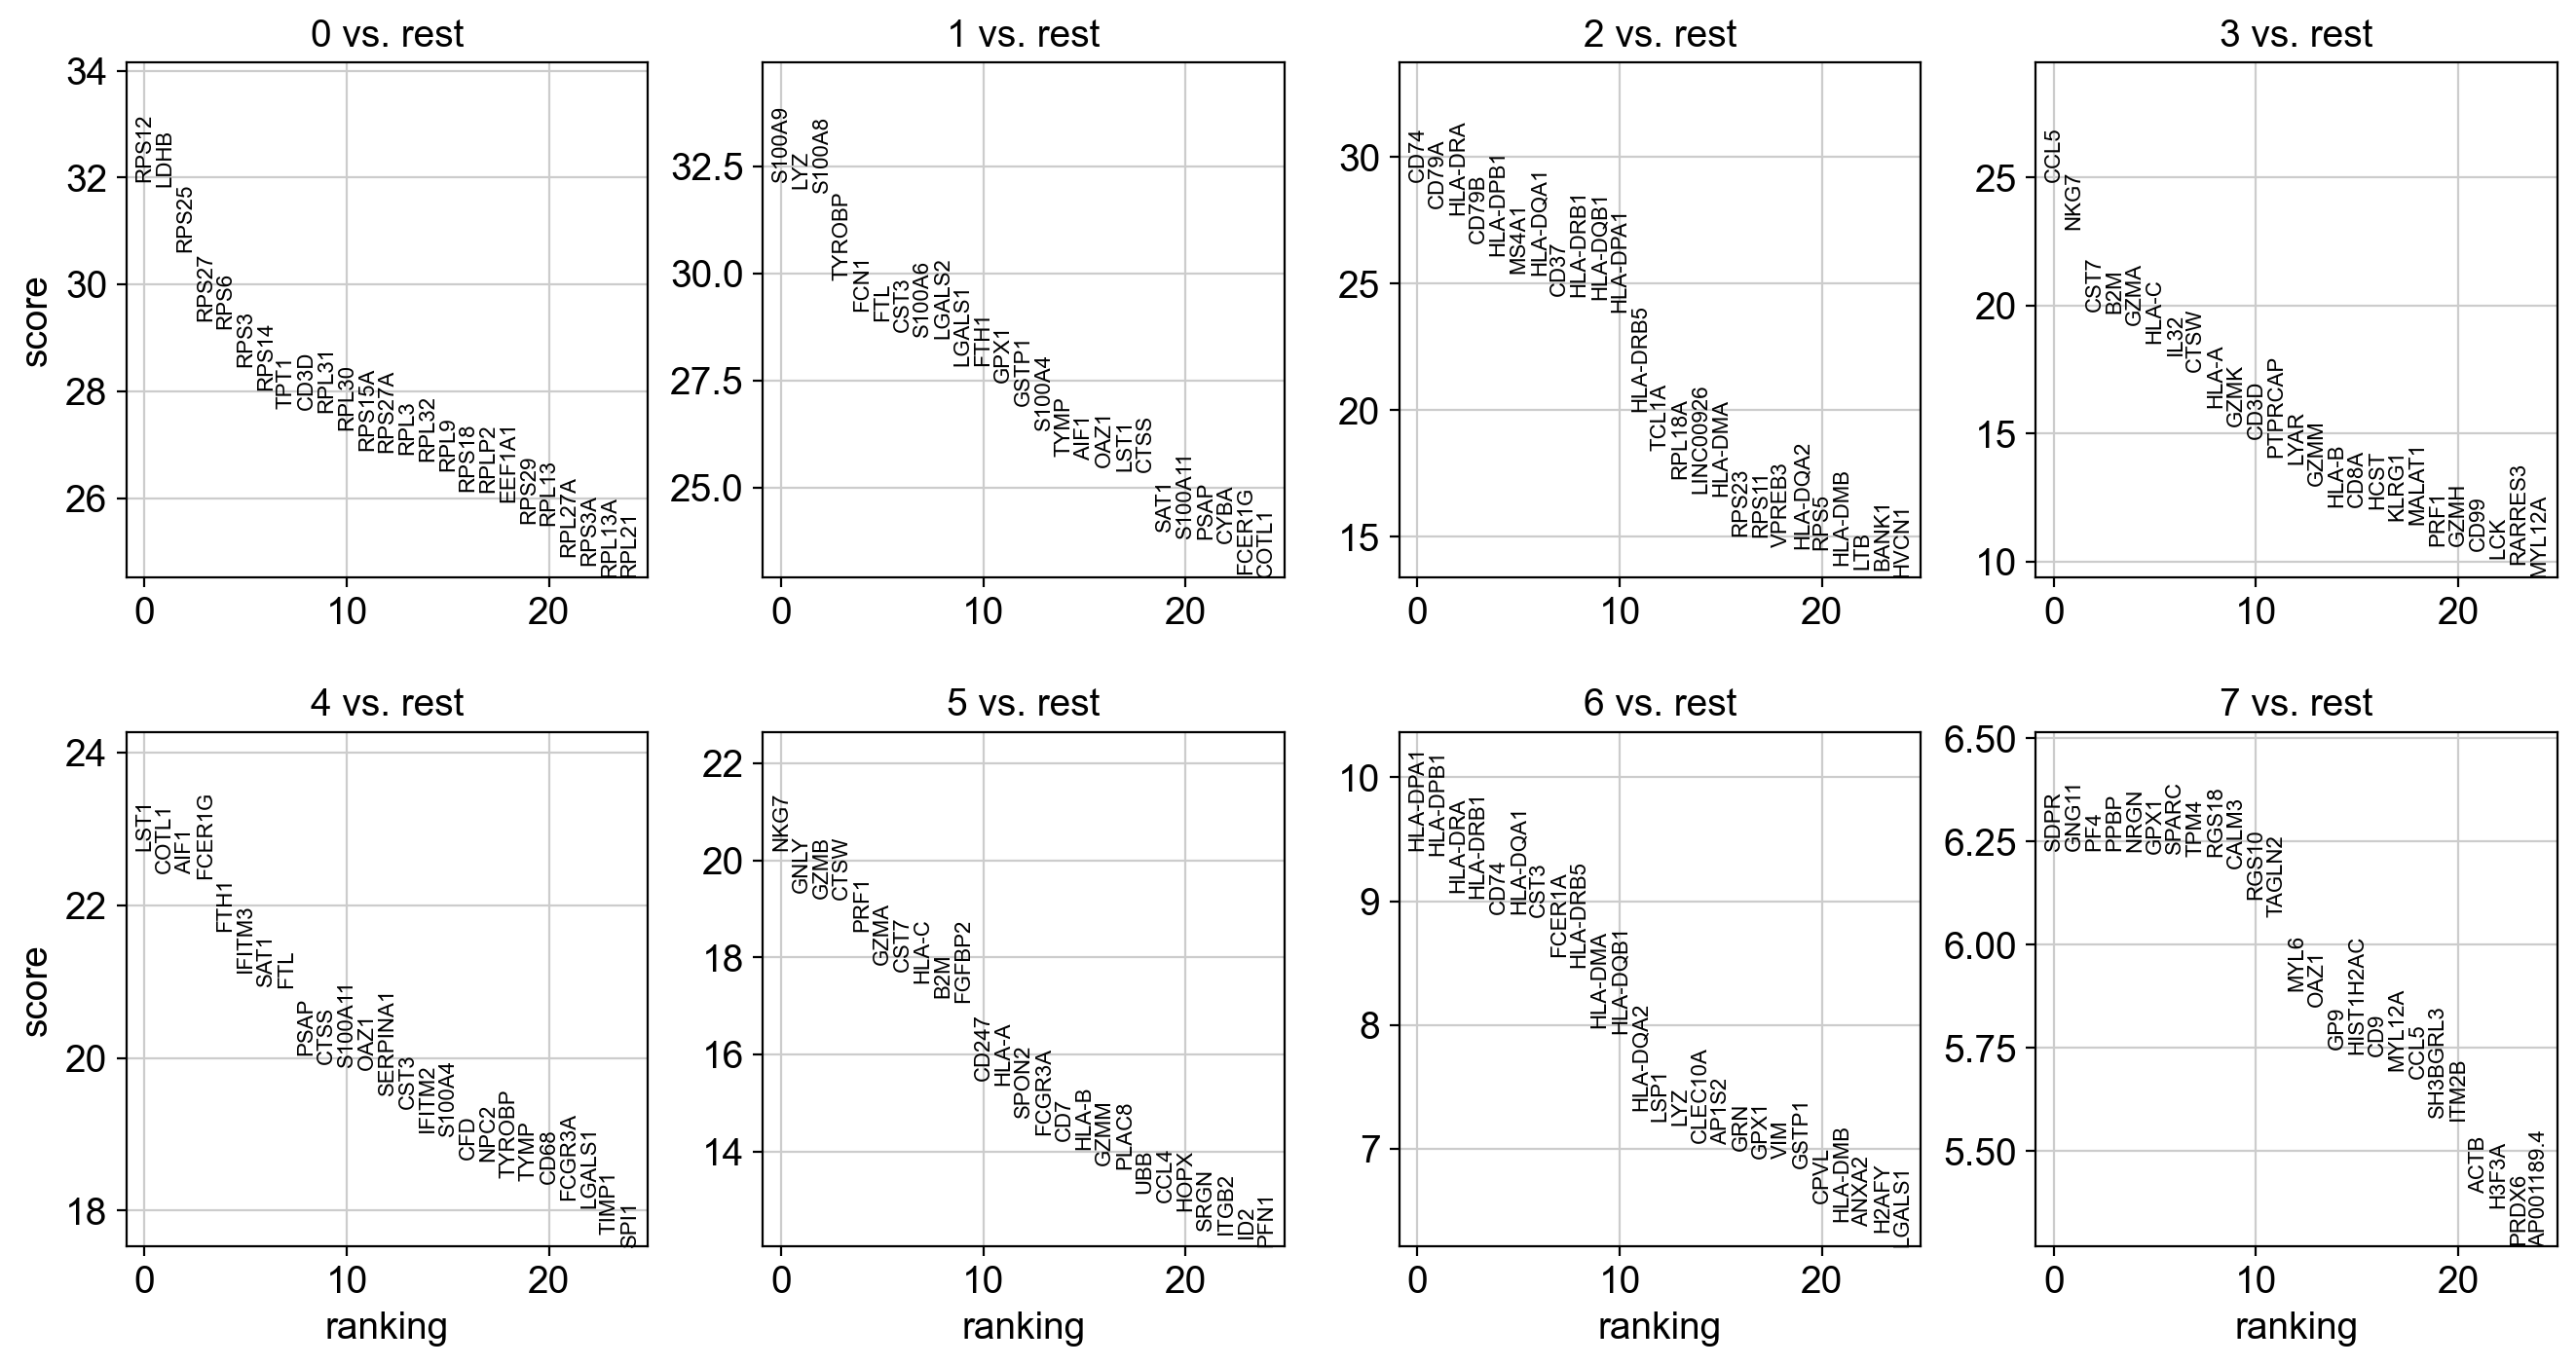

In [18]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

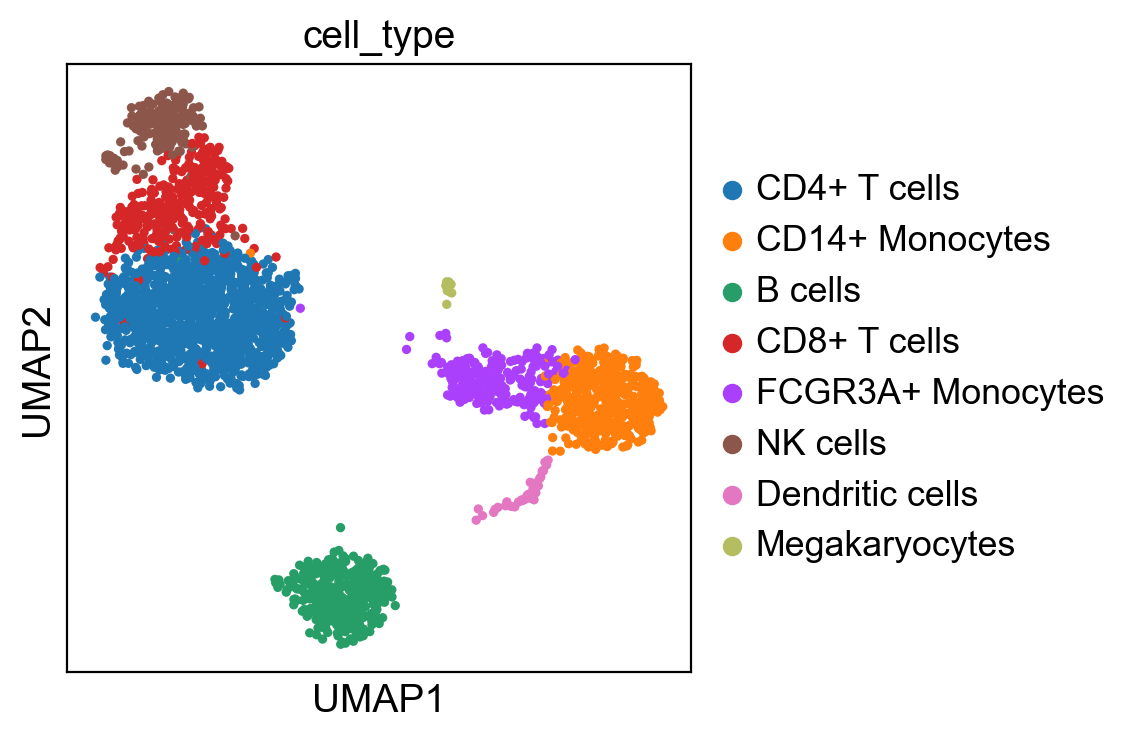

In [19]:
cluster_labels = {
    '0': 'CD4+ T cells',
    '1': 'CD14+ Monocytes',
    '2': 'B cells',
    '3': 'CD8+ T cells',
    '4': 'FCGR3A+ Monocytes',
    '5': 'NK cells',
    '6': 'Dendritic cells',
    '7': 'Megakaryocytes',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_labels).astype('category')
sc.pl.umap(adata, color=['cell_type'])